In [1]:
from __future__ import annotations

import argparse
import gc
import json
import math
import pickle
import sys
from pathlib import Path
from typing import Dict, List, Mapping, Sequence, Tuple

import matplotlib.pyplot as plt
import numpy as np
from scipy import ndimage, signal


DEFAULT_LAYER_ORDER = (
    "D1",
    "D2",
    "D3",
    "LEC",
    "MEC",
    "graph_LEC",
    "graph_MEC",
)
DEFAULT_NUM_SHUFFLES = 20

try:
    from tqdm import tqdm
except Exception:
    tqdm = None

In [2]:
def matlab_style_gauss2d(shape: Sequence[int], sigma: float) -> np.ndarray:
    """Match MATLAB fspecial('gaussian', shape, sigma)."""
    m, n = [(ss - 1.0) / 2.0 for ss in shape]
    y, x = np.ogrid[-m : m + 1, -n : n + 1]
    h = np.exp(-((x * x + y * y) / (2.0 * sigma * sigma)))
    h[h < np.finfo(h.dtype).eps * h.max()] = 0
    sumh = h.sum()
    if sumh != 0:
        h /= sumh
    return h


def load_pickle(path: Path):
    with path.open("rb") as handle:
        return pickle.load(handle)


def load_trajectory(traj_path: str | Path) -> np.ndarray:
    """Load trajectory and return position array of shape (timesteps, 2)."""
    path = Path(traj_path)
    suffix = path.suffix.lower()

    if suffix in {".pk1", ".pkl", ".pickle"}:
        data = load_pickle(path)
        if not isinstance(data, Mapping):
            raise ValueError(f"Expected trajectory pickle dict, got {type(data)!r}")
        x = np.asarray(data["x"], dtype=float)
        y = np.asarray(data["y"], dtype=float)
        return np.column_stack((x, y))

    if suffix in {".csv", ".txt"}:
        data = np.loadtxt(path, delimiter=",")
        if data.ndim == 1:
            data = data.reshape(1, -1)
        if data.shape[1] < 2:
            raise ValueError("Trajectory CSV must contain at least two columns: x, y")
        return np.asarray(data[:, :2], dtype=float)

    raise ValueError(f"Unsupported trajectory format: {path}")


def align_positions_to_time(pos: np.ndarray, time_len: int) -> np.ndarray:
    """Align position rows to activation timesteps."""
    if len(pos) == time_len:
        return pos
    if len(pos) == time_len + 1:
        return pos[:-1]
    if len(pos) == time_len - 1:
        raise ValueError(
            f"Trajectory is shorter than activations: {len(pos)} vs {time_len}"
        )
    raise ValueError(
        f"Could not align trajectory length {len(pos)} with activation length {time_len}"
    )


def _transpose_if_needed(arr: np.ndarray, time_len: int) -> np.ndarray:
    if arr.ndim != 2:
        raise ValueError(f"Expected 2D activations, got shape {arr.shape}")
    if arr.shape[0] == time_len:
        return arr
    if arr.shape[1] == time_len:
        return arr.T
    raise ValueError(
        f"Could not align activation shape {arr.shape} with trajectory length {time_len}"
    )


def load_activations(
    activations_path: str | Path,
    time_len: int,
    layer_order: Sequence[str] = DEFAULT_LAYER_ORDER,
) -> Tuple[np.ndarray, List[Dict[str, int | str]]]:
    """
    Return activation matrix shaped (timesteps, neurons) and metadata per neuron.

    Supported inputs:
    - pickle dict with layer arrays, matching your `encoded_*.pk1`
    - CSV/TXT of combined activations
    - NPY/NPZ containing a single 2D matrix
    """
    path = Path(activations_path)
    suffix = path.suffix.lower()

    if suffix in {".pk1", ".pkl", ".pickle"}:
        encoded = load_pickle(path)
        if not isinstance(encoded, Mapping):
            raise ValueError(f"Expected activation pickle dict, got {type(encoded)!r}")

        matrices: List[np.ndarray] = []
        neuron_meta: List[Dict[str, int | str]] = []
        global_index = 1

        for layer_name in layer_order:
            if layer_name not in encoded:
                continue
            layer_arr = np.asarray(encoded[layer_name], dtype=float)
            layer_arr = _transpose_if_needed(layer_arr, time_len)
            matrices.append(layer_arr)
            for layer_neuron_idx in range(layer_arr.shape[1]):
                neuron_meta.append(
                    {
                        "global_index": global_index,
                        "layer": layer_name,
                        "layer_neuron_index": layer_neuron_idx + 1,
                    }
                )
                global_index += 1

        if not matrices:
            raise ValueError(
                f"No supported layers found in activation pickle. Looked for: {layer_order}"
            )

        return np.hstack(matrices), neuron_meta

    if suffix in {".csv", ".txt"}:
        arr = np.loadtxt(path, delimiter=",", dtype=float)
    elif suffix == ".npy":
        arr = np.load(path)
    elif suffix == ".npz":
        loaded = np.load(path)
        if len(loaded.files) != 1:
            raise ValueError(
                f"NPZ must contain exactly one array for activations, found {loaded.files}"
            )
        arr = loaded[loaded.files[0]]
    else:
        raise ValueError(f"Unsupported activations format: {path}")

    arr = np.asarray(arr, dtype=float)
    arr = _transpose_if_needed(arr, time_len)
    neuron_meta = [
        {"global_index": idx + 1, "layer": "combined", "layer_neuron_index": idx + 1}
        for idx in range(arr.shape[1])
    ]
    return arr, neuron_meta

In [3]:
def occupancy_map_func(
    pos: np.ndarray,
    reso: int = 40,
    win_len: int = 9,
    sigma: float = 3.0,
) -> np.ndarray:
    hist, _, _ = np.histogram2d(pos[:, 0], pos[:, 1], bins=reso * 2)
    gaussian = matlab_style_gauss2d([win_len, win_len], sigma)
    pos_prob = signal.convolve2d(gaussian, hist)
    trim = int(win_len / 2)
    pos_prob = pos_prob[trim:-trim, trim:-trim]
    pos_prob = pos_prob / np.nansum(pos_prob)
    return pos_prob


def build_firing_rate_map(
    responses: np.ndarray,
    pos: np.ndarray,
    occupancy_map: np.ndarray | None = None,
    thresh_param: float = 1.5,
    res_param: int = 80,
    gaussian_shape: Sequence[int] = (9, 9),
    gaussian_sigma: float = 3.0,
    normalization: str = "occupancy",
) -> Tuple[np.ndarray, List[float]]:
    mean_resp = np.mean(responses)
    std_resp = np.std(responses)
    thresh = mean_resp + (thresh_param * std_resp)
    firing_idx = np.flatnonzero(responses > thresh)

    xmin, xmax = float(np.min(pos[:, 0])), float(np.max(pos[:, 0]))
    ymin, ymax = float(np.min(pos[:, 1])), float(np.max(pos[:, 1]))

    x = np.linspace(xmin, xmax, res_param)
    y = np.linspace(ymin, ymax, res_param)
    firing_map = np.zeros((res_param, res_param), dtype=float)

    if firing_idx.size:
        firing_positions = pos[firing_idx, :2]
        firing_values = responses[firing_idx]

        for ii in range(len(firing_positions)):
            col = int(np.argmin(np.abs(firing_positions[ii, 0] - x)))
            row = int(np.argmin(np.abs(firing_positions[ii, 1] - y)))
            firing_map[row, col] = max(firing_values[ii], firing_map[row, col])

    if normalization == "occupancy" and occupancy_map is not None:
        occ = np.asarray(occupancy_map, dtype=float).copy()
        occ[occ == 0] = np.nan
        with np.errstate(divide="ignore", invalid="ignore"):
            firing_map = np.divide(
                firing_map,
                occ,
                out=np.zeros_like(firing_map, dtype=float),
                where=np.isfinite(occ) & (occ != 0),
            )
        firing_map = np.nan_to_num(firing_map, nan=0.0)
    else:
        max_value = float(np.nanmax(firing_map)) if firing_map.size else 0.0
        if max_value > 0:
            firing_map = firing_map / max_value

    gaussian = matlab_style_gauss2d(gaussian_shape, gaussian_sigma)
    spikes_smooth = signal.convolve2d(gaussian, firing_map)
    trim = int(gaussian_shape[0] // 2)
    spikes_smooth = spikes_smooth[trim:-trim, trim:-trim]
    extent = [xmin, xmax, ymin, ymax]
    return spikes_smooth, extent

In [4]:
def point_corr(
    map1: np.ndarray,
    map2: np.ndarray,
    row_off: int,
    col_off: int,
    bins: int,
) -> float:
    num_rows = bins - abs(row_off)
    num_cols = bins - abs(col_off)

    if row_off > 0:
        r_st1 = abs(row_off)
        r_st2 = 0
    else:
        r_st1 = 0
        r_st2 = abs(row_off)

    if col_off > 0:
        c_st1 = abs(col_off)
        c_st2 = 0
    else:
        c_st1 = 0
        c_st2 = abs(col_off)

    block1 = map1[r_st1 : r_st1 + num_rows, c_st1 : c_st1 + num_cols]
    block2 = map2[r_st2 : r_st2 + num_rows, c_st2 : c_st2 + num_cols]
    valid = ~np.isnan(block1) & ~np.isnan(block2)
    nb = int(valid.sum())
    if nb < 20:
        return 0.0

    x = block1[valid]
    y = block2[valid]
    sum_x = x.sum()
    sum_y = y.sum()
    sum_xy = np.sum(x * y)
    sum_x2 = np.sum(x * x)
    sum_y2 = np.sum(y * y)

    var_x = sum_x2 - (sum_x * sum_x) / nb
    var_y = sum_y2 - (sum_y * sum_y) / nb
    cov_xy = sum_xy - (sum_x * sum_y) / nb

    if (var_x <= 0 <= var_y) or (var_y <= 0 <= var_x):
        return 0.0
    if var_x <= 0 or var_y <= 0:
        return 0.0

    return float(cov_xy / math.sqrt(var_x * var_y))


In [5]:
def correlation_map(map1: np.ndarray, map2: np.ndarray) -> np.ndarray:
    bins = map1.shape[0]
    n = bins + round(0.64 * bins)
    if n % 2 == 0:
        n -= 1
    center_bin = (n + 1) // 2

    corr = np.zeros((n, n), dtype=float)
    for ii in range(n):
        row_off = ii + 1 - center_bin
        for jj in range(n):
            col_off = jj + 1 - center_bin
            corr[ii, jj] = point_corr(map1, map2, row_off, col_off, bins)
    return corr

In [6]:
def _crop_center(rotated: np.ndarray, target_shape: Tuple[int, int]) -> np.ndarray:
    start0 = (rotated.shape[0] - target_shape[0]) // 2
    start1 = (rotated.shape[1] - target_shape[1]) // 2
    return rotated[start0 : start0 + target_shape[0], start1 : start1 + target_shape[1]]


def corrcoef2(a: np.ndarray, b: np.ndarray) -> float:
    a_flat = np.asarray(a, dtype=float).ravel()
    b_flat = np.asarray(b, dtype=float).ravel()
    valid = ~np.isnan(a_flat) & ~np.isnan(b_flat)
    if valid.sum() < 2:
        return 0.0
    a_flat = a_flat[valid]
    b_flat = b_flat[valid]
    if np.std(a_flat) == 0 or np.std(b_flat) == 0:
        return 0.0
    return float(np.corrcoef(a_flat, b_flat)[0, 1])

In [7]:
def gridscore(masked_corr: np.ndarray) -> float:
    c60 = ndimage.rotate(masked_corr, 60, reshape=True)
    c60_2 = _crop_center(c60, masked_corr.shape)
    r60 = corrcoef2(masked_corr, c60_2)

    c120 = ndimage.rotate(masked_corr, 120, reshape=True)
    c120_2 = _crop_center(c120, masked_corr.shape)
    r120 = corrcoef2(masked_corr, c120_2)

    c30 = ndimage.rotate(masked_corr, 30, reshape=True)
    c30_2 = _crop_center(c30, masked_corr.shape)
    r30 = corrcoef2(masked_corr, c30_2)

    c90 = ndimage.rotate(masked_corr, 90, reshape=False)
    r90 = corrcoef2(masked_corr, c90)

    c150 = ndimage.rotate(masked_corr, 150, reshape=True)
    c150_2 = _crop_center(c150, masked_corr.shape)
    r150 = corrcoef2(masked_corr, c150_2)

    return float(min(r60, r120) - max(r30, r90, r150))


def _regional_maxima(arr: np.ndarray) -> np.ndarray:
    max_filtered = ndimage.maximum_filter(arr, size=3, mode="nearest")
    return (arr == max_filtered) & np.isfinite(arr)


In [8]:
def get_original_grid_score(spikes_smooth: np.ndarray, win_len: int = 7) -> float:
    rotated_img = ndimage.rotate(spikes_smooth, 90, reshape=True)
    trim = round(win_len / 2)
    rotated_img = rotated_img[trim:-trim, trim:-trim]

    corr = correlation_map(rotated_img, rotated_img)
    rows, cols = corr.shape
    central_peak = np.array([0.5 * (rows + 1), 0.5 * (cols + 1)], dtype=float)

    maxima = _regional_maxima(corr)
    peakx, peaky = np.where(maxima)
    if peakx.size == 0:
        return float("nan")

    peak_matrix = np.column_stack((peakx + 1, peaky + 1))
    distances = np.linalg.norm(peak_matrix - central_peak, axis=1)
    distascending = np.sort(distances)
    if len(distascending) < 6:
        return float("nan")

    radius1 = np.max(distascending[1 : min(6, len(distascending))]) + 3
    rr, cc = np.meshgrid(np.arange(1, len(corr) + 1), np.arange(1, len(corr) + 1))
    circlemask1 = np.sqrt((rr - central_peak[0]) ** 2 + (cc - central_peak[1]) ** 2) <= radius1
    corr_ring = corr * circlemask1

    radius2 = 12
    circlemask2 = np.sqrt((rr - central_peak[0]) ** 2 + (cc - central_peak[1]) ** 2) <= radius2
    corr_ring = corr_ring * (~circlemask2)

    return gridscore(corr_ring)

In [9]:
def build_autocorrelation_ring(
    spikes_smooth: np.ndarray,
    win_len: int = 7,
) -> Tuple[np.ndarray, np.ndarray, np.ndarray]:
    rotated_img = ndimage.rotate(spikes_smooth, 90, reshape=True)
    trim = round(win_len / 2)
    rotated_img = rotated_img[trim:-trim, trim:-trim]

    corr = correlation_map(rotated_img, rotated_img)
    rows, cols = corr.shape
    central_peak = np.array([0.5 * (rows + 1), 0.5 * (cols + 1)], dtype=float)

    maxima = _regional_maxima(corr)
    peakx, peaky = np.where(maxima)
    if peakx.size == 0:
        return corr, corr, rotated_img

    peak_matrix = np.column_stack((peakx + 1, peaky + 1))
    distances = np.linalg.norm(peak_matrix - central_peak, axis=1)
    distascending = np.sort(distances)
    if len(distascending) < 6:
        return corr, corr, rotated_img

    radius1 = np.max(distascending[1 : min(6, len(distascending))]) + 3
    rr, cc = np.meshgrid(np.arange(1, len(corr) + 1), np.arange(1, len(corr) + 1))
    circlemask1 = np.sqrt((rr - central_peak[0]) ** 2 + (cc - central_peak[1]) ** 2) <= radius1
    corr_ring = corr * circlemask1

    radius2 = 12
    circlemask2 = np.sqrt((rr - central_peak[0]) ** 2 + (cc - central_peak[1]) ** 2) <= radius2
    corr_ring = corr_ring * (~circlemask2)
    return corr, corr_ring, rotated_img

In [10]:
def score_single_neuron(
    responses: np.ndarray,
    pos: np.ndarray,
    occupancy_map: np.ndarray,
    num_shuffles: int,
    rng: np.random.Generator,
    thresh_param: float,
    res_param: int,
) -> Dict[str, object]:
    map_res = int(occupancy_map.shape[0]) if occupancy_map is not None else res_param
    original_map, original_extent = build_firing_rate_map(
        responses,
        pos,
        occupancy_map,
        thresh_param=thresh_param,
        res_param=map_res,
    )
    autocorr_map, autocorr_ring, _ = build_autocorrelation_ring(original_map)
    original_hgs = gridscore(autocorr_ring)

    shuffled_scores = np.zeros(num_shuffles, dtype=float)
    for shuffle_idx in range(num_shuffles):
        shuffled_resp = rng.permutation(responses)
        shuffled_map, _ = build_firing_rate_map(
            shuffled_resp,
            pos,
            occupancy_map,
            thresh_param=thresh_param,
            res_param=map_res,
        )
        _, shuffled_ring, _ = build_autocorrelation_ring(shuffled_map)
        shuffled_scores[shuffle_idx] = gridscore(shuffled_ring)

    threshold_95 = float(np.nanpercentile(shuffled_scores, 95))
    is_grid = bool(np.isfinite(original_hgs) and original_hgs > threshold_95)

    return {
        "original_hgs": float(original_hgs),
        "shuffle_threshold_95": threshold_95,
        "is_grid_cell": is_grid,
        "shuffled_hgs": shuffled_scores,
        "original_map": original_map,
        "original_extent": original_extent,
        "autocorr_map": autocorr_map,
        "autocorr_ring": autocorr_ring,
    }


In [11]:
def save_neuron_plots(
    output_dir: str | Path,
    neuron_filename: str,
    layer_name: str,
    global_index: int,
    layer_neuron_index: int,
    firing_map: np.ndarray,
    firing_extent: Sequence[float],
    autocorr_map: np.ndarray,
    hgs: float,
    threshold_95: float,
    is_grid: bool,
) -> None:
    output_path = Path(output_dir)
    output_path.mkdir(parents=True, exist_ok=True)

    fig, axes = plt.subplots(1, 2, figsize=(10, 4))
    rotated = ndimage.rotate(firing_map, 90)
    rotated_extent = [firing_extent[2], firing_extent[3], firing_extent[0], firing_extent[1]]
    axes[0].imshow(
        rotated,
        origin="lower",
        cmap="jet",
        aspect="auto",
        extent=rotated_extent,
    )
    axes[0].set_title(f"{layer_name} #{layer_neuron_index} firing map")
    axes[0].axis("off")

    axes[1].imshow(autocorr_map, origin="lower", cmap="coolwarm", aspect="auto")
    axes[1].set_title(
        f"global #{global_index} autocorr\nHGS={hgs:.3f}, thr95={threshold_95:.3f}, grid={is_grid}"
    )
    axes[1].axis("off")

    fig.tight_layout()
    fig.savefig(output_path / f"{neuron_filename}.png", dpi=150, bbox_inches="tight")
    plt.close(fig)

In [12]:
def score_grid_cells(
    activations_path: str | Path,
    trajectory_path: str | Path,
    num_shuffles: int = DEFAULT_NUM_SHUFFLES,
    thresh_param: float = 1.5,
    res_param: int = 40,
    random_seed: int = 0,
    plots_dir: str | Path | None = None,
    checkpoint_output_path: str | Path | None = None,
) -> Dict[str, object]:
    raw_pos = load_trajectory(trajectory_path)
    activations, neuron_meta = load_activations(activations_path, time_len=len(raw_pos) - 1 if len(raw_pos) > 1 else len(raw_pos))
    pos = align_positions_to_time(raw_pos, activations.shape[0])
    occupancy_map = occupancy_map_func(pos, reso=res_param)
    rng = np.random.default_rng(random_seed)

    results: List[Dict[str, object]] = []
    grid_indices: List[int] = []
    total_neurons = activations.shape[1]
    iterator = range(total_neurons)
    if tqdm is not None:
        iterator = tqdm(iterator, total=total_neurons, desc="Scoring neurons", unit="neuron")

    for neuron_idx in iterator:
        neuron_result = score_single_neuron(
            activations[:, neuron_idx],
            pos,
            occupancy_map,
            num_shuffles=num_shuffles,
            rng=rng,
            thresh_param=thresh_param,
            res_param=res_param,
        )
        meta = dict(neuron_meta[neuron_idx])
        meta.update(neuron_result)
        meta["shuffled_hgs"] = np.asarray(meta["shuffled_hgs"], dtype=float).tolist()
        neuron_prefix = "grid_neuron" if bool(meta["is_grid_cell"]) else "neuron"
        neuron_filename = f"{neuron_prefix}_{int(meta['global_index']):03d}"
        if plots_dir is not None:
            layer_plot_dir = Path(plots_dir) / str(meta["layer"])
            save_neuron_plots(
                layer_plot_dir,
                neuron_filename,
                str(meta["layer"]),
                int(meta["global_index"]),
                int(meta["layer_neuron_index"]),
                np.asarray(meta["original_map"], dtype=float),
                list(meta["original_extent"]),
                np.asarray(meta["autocorr_map"], dtype=float),
                float(meta["original_hgs"]),
                float(meta["shuffle_threshold_95"]),
                bool(meta["is_grid_cell"]),
            )
        meta["plot_filename"] = f"{str(meta['layer'])}/{neuron_filename}.png"
        meta.pop("original_map", None)
        meta.pop("original_extent", None)
        meta.pop("autocorr_map", None)
        meta.pop("autocorr_ring", None)
        results.append(meta)

        if bool(meta["is_grid_cell"]):
            grid_indices.append(int(meta["global_index"]))

        if checkpoint_output_path is not None:
            save_results(
                checkpoint_output_path,
                {
                    "grid_cell_indices": grid_indices,
                    "results": results,
                    "num_neurons": int(activations.shape[1]),
                    "num_grid_cells": int(len(grid_indices)),
                    "num_shuffles": int(num_shuffles),
                    "completed_neurons": int(neuron_idx + 1),
                },
            )

        del neuron_result
        del meta
        gc.collect()

        if tqdm is None:
            progress = ((neuron_idx + 1) / total_neurons) * 100.0
            print(
                f"\rScoring neurons: {neuron_idx + 1}/{total_neurons} ({progress:.1f}%)",
                end="",
                flush=True,
            )

    if tqdm is None and total_neurons:
        print()

    return {
        "grid_cell_indices": grid_indices,
        "results": results,
        "num_neurons": int(activations.shape[1]),
        "num_grid_cells": int(len(grid_indices)),
        "num_shuffles": int(num_shuffles),
    }

In [13]:
def save_results(output_path: str | Path, payload: Mapping[str, object]) -> None:
    path = Path(output_path)
    path.parent.mkdir(parents=True, exist_ok=True)
    with path.open("w", encoding="utf-8") as handle:
        json.dump(payload, handle, indent=2)


def ensure_output_dirs(
    output_path: str | Path,
    plots_dir: str | Path | None,
    layer_names: Sequence[str] = DEFAULT_LAYER_ORDER,
) -> None:
    output_path = Path(output_path)
    output_path.parent.mkdir(parents=True, exist_ok=True)
    if plots_dir is None:
        return
    plots_root = Path(plots_dir)
    plots_root.mkdir(parents=True, exist_ok=True)
    for layer_name in layer_names:
        (plots_root / layer_name).mkdir(parents=True, exist_ok=True)

In [14]:
def default_output_paths(
    activations_path: str | Path,
    root_dir: str | Path | None = None,
) -> Tuple[Path, Path]:
    if root_dir is None:
        root_dir = Path(__file__).resolve().parent.parent / "spatial cell results"
    activation_stem = Path(activations_path).stem
    prefixes = ("encoded_ec_hpc_", "encoded_")
    run_name = activation_stem
    for prefix in prefixes:
        if activation_stem.startswith(prefix):
            run_name = activation_stem[len(prefix) :]
            break
    if run_name.endswith("_30epochs"):
        run_name = run_name[: -len("_30epochs")]

    run_dir = Path(root_dir) / run_name
    json_path = run_dir / "grid cells" / "grid_cell_scores.json"
    plots_dir = run_dir / "firing rate maps"
    return json_path, plots_dir

In [15]:
def main() -> None:
    parser = argparse.ArgumentParser(
        description=(
            "Compute MATLAB-style hexagonal gridness scores from neuron activations "
            "and trajectory positions."
        )
    )
    parser.add_argument("--activations", required=True, help="Path to encoded activations")
    parser.add_argument("--trajectory", required=True, help="Path to trajectory file")
    parser.add_argument(
        "--output",
        default=None,
        help="Path to JSON output containing grid-cell indices and HGS scores",
    )
    parser.add_argument(
        "--num-shuffles",
        type=int,
        default=DEFAULT_NUM_SHUFFLES,
        help="Number of shuffled controls per neuron",
    )
    parser.add_argument(
        "--threshold-param",
        type=float,
        default=1.5,
        help="Threshold factor used in firing-rate map construction",
    )
    parser.add_argument(
        "--resolution",
        type=int,
        default=40,
        help="Spatial rate-map resolution parameter",
    )
    parser.add_argument(
        "--seed",
        type=int,
        default=0,
        help="Random seed for shuffling",
    )
    parser.add_argument(
        "--plots-dir",
        default=None,
        help="Optional directory to save one plot per neuron with firing map and autocorrelation",
    )
    if len(sys.argv) == 1:
        print("Enter the input file paths and press Enter after each one.")
        activations = input("Activations path: ").strip().strip('"')
        trajectory = input("Trajectory path: ").strip().strip('"')
        args = parser.parse_args(
            ["--activations", activations, "--trajectory", trajectory]
        )
    else:
        args = parser.parse_args()

    output_path: Path
    plots_dir: Path | None
    if args.output is None and args.plots_dir is None:
        output_path, inferred_plots_dir = default_output_paths(args.activations)
        plots_dir = inferred_plots_dir
    else:
        output_path = Path(args.output) if args.output is not None else default_output_paths(args.activations)[0]
        plots_dir = Path(args.plots_dir) if args.plots_dir is not None else None

    ensure_output_dirs(output_path, plots_dir)

    payload = score_grid_cells(
        activations_path=args.activations,
        trajectory_path=args.trajectory,
        num_shuffles=args.num_shuffles,
        thresh_param=args.threshold_param,
        res_param=args.resolution,
        random_seed=args.seed,
        plots_dir=plots_dir,
        checkpoint_output_path=output_path,
    )
    save_results(output_path, payload)

    print(f"Saved grid-cell scores to: {output_path}")
    if plots_dir is not None:
        print(f"Saved neuron plots under: {plots_dir}")
    print(f"Total neurons: {payload['num_neurons']}")
    print(f"Grid cells: {payload['num_grid_cells']}")
    print(f"Indices: {payload['grid_cell_indices']}")



In [16]:
# ============================================================================
# GRID CELL FUNCTIONS  (delegated to grid_cell_scorer.py)
# ============================================================================

def firing_rate_map_grid(ot, all_dat, occupancy_map, thresh_param=1.5, res_param=40):
    """Generate firing rate map for grid cell analysis using the canonical scorer."""
    map_res = int(occupancy_map.shape[0]) if occupancy_map is not None else res_param
    spikes_smooth, extent = gcs.build_firing_rate_map(
        responses=ot,
        pos=all_dat,
        occupancy_map=occupancy_map,
        thresh_param=thresh_param,
        res_param=map_res,
    )
    return spikes_smooth, extent


def detect_grid_cells(pos_out, encoded_data, lim=1.5, reso=40, num_shuffles=20, random_seed=0):
    """
    Detect grid cells using HGS with shuffle-based significance test.
    Returns:
        grid_cells       — list of 1-based global neuron indices
        autocorr_data    — dict mapping global_index -> {autocorr_map, autocorr_ring, hgs, threshold_95, layer, neuron_within_layer}
    """
    layer_order = ('D1', 'D2', 'D3', 'LEC', 'MEC', 'graph_LEC', 'graph_MEC')
    occupancy_map = gcs.occupancy_map_func(pos_out, reso=reso)
    rng = np.random.default_rng(random_seed)

    grid_cells = []
    autocorr_data = {}
    global_index = 1

    for layer_name in layer_order:
        if layer_name not in encoded_data:
            continue
        layer_arr = np.asarray(encoded_data[layer_name], dtype=float)
        n_neurons = layer_arr.shape[1]  # shape is (timesteps, neurons)

        for neuron_idx in range(n_neurons):
            result = gcs.score_single_neuron(
                responses=layer_arr[:, neuron_idx],
                pos=pos_out,
                occupancy_map=occupancy_map,
                num_shuffles=num_shuffles,
                rng=rng,
                thresh_param=lim,
                res_param=reso,
            )
            if result['is_grid_cell']:
                grid_cells.append(global_index)
                autocorr_data[global_index] = {
                    'autocorr_map':  result['autocorr_map'],
                    'autocorr_ring': result['autocorr_ring'],
                    'hgs':           result['original_hgs'],
                    'threshold_95':  result['shuffle_threshold_95'],
                    'layer':         layer_name,
                    'neuron_within_layer': neuron_idx + 1,
                }
            global_index += 1

    return grid_cells, autocorr_data

In [17]:
import pickle
import numpy as np

# ==========================================================
# USER SETTINGS
# ==========================================================

PKL_PATH = "/Users/ais/Desktop/2026_Summer/2d_hippocampal_cells/2D-traj-results-training.pkl"
# Number of trajectories to combine
N_TRAJ = 5

# Random seed (change for a different random selection)
RANDOM_SEED = 42

# Remove initial timesteps
REMOVE_FIRST = 50

# ==========================================================

# ---------- Load ----------
with open(PKL_PATH, "rb") as f:
    data = pickle.load(f)

# ---------- Random trajectory selection ----------
rng = np.random.default_rng(RANDOM_SEED)

TRAJ_INDICES = rng.choice(
    data["ground_truth"].shape[0],
    size=N_TRAJ,
    replace=False,
)

TRAJ_INDICES = np.sort(TRAJ_INDICES)

print(f"Selected trajectories: {TRAJ_INDICES}")

# ---------- Build converted dictionary ----------
converted = {}

# Positions
converted["trajectory"] = np.concatenate(
    [data["ground_truth"][i, REMOVE_FIRST:, :] for i in TRAJ_INDICES],
    axis=0,
)

# Layer mapping
layer_map = {
    "d1": "D1",
    "z1": "LEC",
    "d2": "D2",
    "z2": "MEC",
    "d3": "D3",
    "z3": "graph_LEC",
    "d4": "graph_MEC",
}

for old_key, new_key in layer_map.items():

    converted[new_key] = np.concatenate(
        [data[old_key][i, REMOVE_FIRST:, :] for i in TRAJ_INDICES],
        axis=0,
    )

# ---------- Summary ----------
print("\nConverted dictionary:")
for k, v in converted.items():
    print(f"{k:12s} {v.shape}")

Selected trajectories: [ 44 216 219 325 384]

Converted dictionary:
trajectory   (2250, 2)
D1           (2250, 100)
LEC          (2250, 100)
D2           (2250, 100)
MEC          (2250, 100)
D3           (2250, 100)
graph_LEC    (2250, 100)
graph_MEC    (2250, 100)


In [24]:
# =====================================================
# Use preprocessed combined trajectories
# =====================================================

raw_pos = converted["trajectory"]

layer_order = [
    "D1",
    "D2",
    "D3",
    "LEC",
    "MEC",
    "graph_LEC",
    "graph_MEC",
]

matrices = []
neuron_meta = []

global_index = 1

for layer_name in layer_order:

    arr = converted[layer_name]

    matrices.append(arr)

    for neuron in range(arr.shape[1]):

        neuron_meta.append(
            {
                "global_index": global_index,
                "layer": layer_name,
                "layer_neuron_index": neuron + 1,
            }
        )

        global_index += 1

activations = np.hstack(matrices)

print("Positions:", raw_pos.shape)
print("Activations:", activations.shape)

Positions: (2250, 2)
Activations: (2250, 700)


In [25]:
# Build occupancy map

occupancy_map = occupancy_map_func(
    raw_pos,
    reso=40,
)

print(occupancy_map.shape)

(80, 80)


In [26]:
rng = np.random.default_rng(0)

result = score_single_neuron(
    responses=activations[:, 0],
    pos=raw_pos,
    occupancy_map=occupancy_map,
    num_shuffles=20,
    rng=rng,
    thresh_param=1.5,
    res_param=40,
)

print(result["original_hgs"])
print(result["shuffle_threshold_95"])
print(result["is_grid_cell"])

/var/folders/wj/5j3twf2d2t73f60tspzghv400000gn/T/ipykernel_41912/1233090477.py:30: ComplexWarning: Casting complex values to real discards the imaginary part
  firing_map[row, col] = max(firing_values[ii], firing_map[row, col])


-0.05946416408715002
0.0004445587463930258
False


In [27]:
TEST_NEURONS = 10

for neuron in range(TEST_NEURONS):

    result = score_single_neuron(
        responses=activations[:, neuron],
        pos=raw_pos,
        occupancy_map=occupancy_map,
        num_shuffles=5,
        rng=rng,
        thresh_param=1.5,
        res_param=40,
    )

/var/folders/wj/5j3twf2d2t73f60tspzghv400000gn/T/ipykernel_41912/1233090477.py:30: ComplexWarning: Casting complex values to real discards the imaginary part
  firing_map[row, col] = max(firing_values[ii], firing_map[row, col])


In [28]:
from tqdm.auto import tqdm

rng = np.random.default_rng(0)

results = []



for neuron in tqdm(range(activations.shape[1])):

    result = score_single_neuron(
        responses=activations[:, neuron],
        pos=raw_pos,
        occupancy_map=occupancy_map,
        num_shuffles=20,
        rng=rng,
        thresh_param=1.5,
        res_param=40,
    )

    meta = neuron_meta[neuron].copy()
    meta.update(result)

    results.append(meta)

print(f"Finished scoring {len(results)} neurons.")

/opt/anaconda3/envs/venv_3.12/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
  0%|          | 0/700 [00:00<?, ?it/s]/var/folders/wj/5j3twf2d2t73f60tspzghv400000gn/T/ipykernel_41912/1233090477.py:30: ComplexWarning: Casting complex values to real discards the imaginary part
  firing_map[row, col] = max(firing_values[ii], firing_map[row, col])
  3%|▎         | 21/700 [07:20<3:57:24, 20.98s/it]


KeyboardInterrupt: 

In [29]:
grid_cells = [r for r in results if r["is_grid_cell"]]


print(f"Grid cells found: {len(grid_cells)}")

Grid cells found: 1


In [30]:
from collections import Counter

layer_counts = Counter(r["layer"] for r in grid_cells)

print(layer_counts)

Counter({'D1': 1})


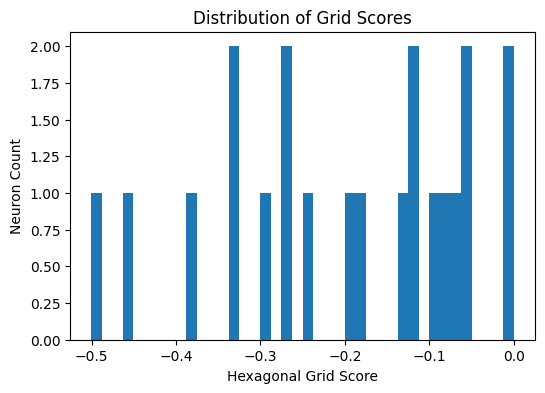

In [31]:
import matplotlib.pyplot as plt

scores = [r["original_hgs"] for r in results]

plt.figure(figsize=(6,4))
plt.hist(scores, bins=40)
plt.xlabel("Hexagonal Grid Score")
plt.ylabel("Neuron Count")
plt.title("Distribution of Grid Scores")
plt.show()

In [ ]:
"""import json
from pathlib import Path

# ==========================================================
# SAVE LOCATION
# ==========================================================

SAVE_DIR = Path("/Users/ais/Desktop/2026_Summer/2d_hippocampal_cells")
SAVE_DIR.mkdir(parents=True, exist_ok=True)

OUTPUT_FILE = SAVE_DIR / "grid_cell_scores.json"

# ==========================================================
# Prepare results for JSON
# ==========================================================

results_to_save = []

for r in results:

    rr = r.copy()

    # Convert NumPy arrays to lists
    if "shuffled_hgs" in rr:
        rr["shuffled_hgs"] = np.asarray(rr["shuffled_hgs"]).tolist()

    # Remove large arrays (they make the JSON huge)
    rr.pop("original_map", None)
    rr.pop("original_extent", None)
    rr.pop("autocorr_map", None)
    rr.pop("autocorr_ring", None)

    results_to_save.append(rr)

grid_indices = [
    r["global_index"]
    for r in results_to_save
    if r["is_grid_cell"]
]

payload = {
    "num_neurons": len(results_to_save),
    "num_grid_cells": len(grid_indices),
    "grid_cell_indices": grid_indices,
    "selected_trajectories": TRAJ_INDICES.tolist(),
    "num_combined_trajectories": N_TRAJ,
    "removed_initial_timesteps": REMOVE_FIRST,
    "random_seed": RANDOM_SEED,
    "num_shuffles": 20,
    "layer_order": layer_order,
    "results": results_to_save,
}

# ==========================================================
# Save JSON
# ==========================================================

with open(OUTPUT_FILE, "w") as f:
    json.dump(payload, f, indent=2)

print(f"Saved results to:\n{OUTPUT_FILE}")
print(f"Grid cells found: {len(grid_indices)}")"""

Saved results to:
/Users/ais/Desktop/2026_Summer/2d_hippocampal_cells/grid_cell_scores.json
Grid cells found: 52


Found 52 grid cells.


/var/folders/wj/5j3twf2d2t73f60tspzghv400000gn/T/ipykernel_30979/1233090477.py:30: ComplexWarning: Casting complex values to real discards the imaginary part
  firing_map[row, col] = max(firing_values[ii], firing_map[row, col])


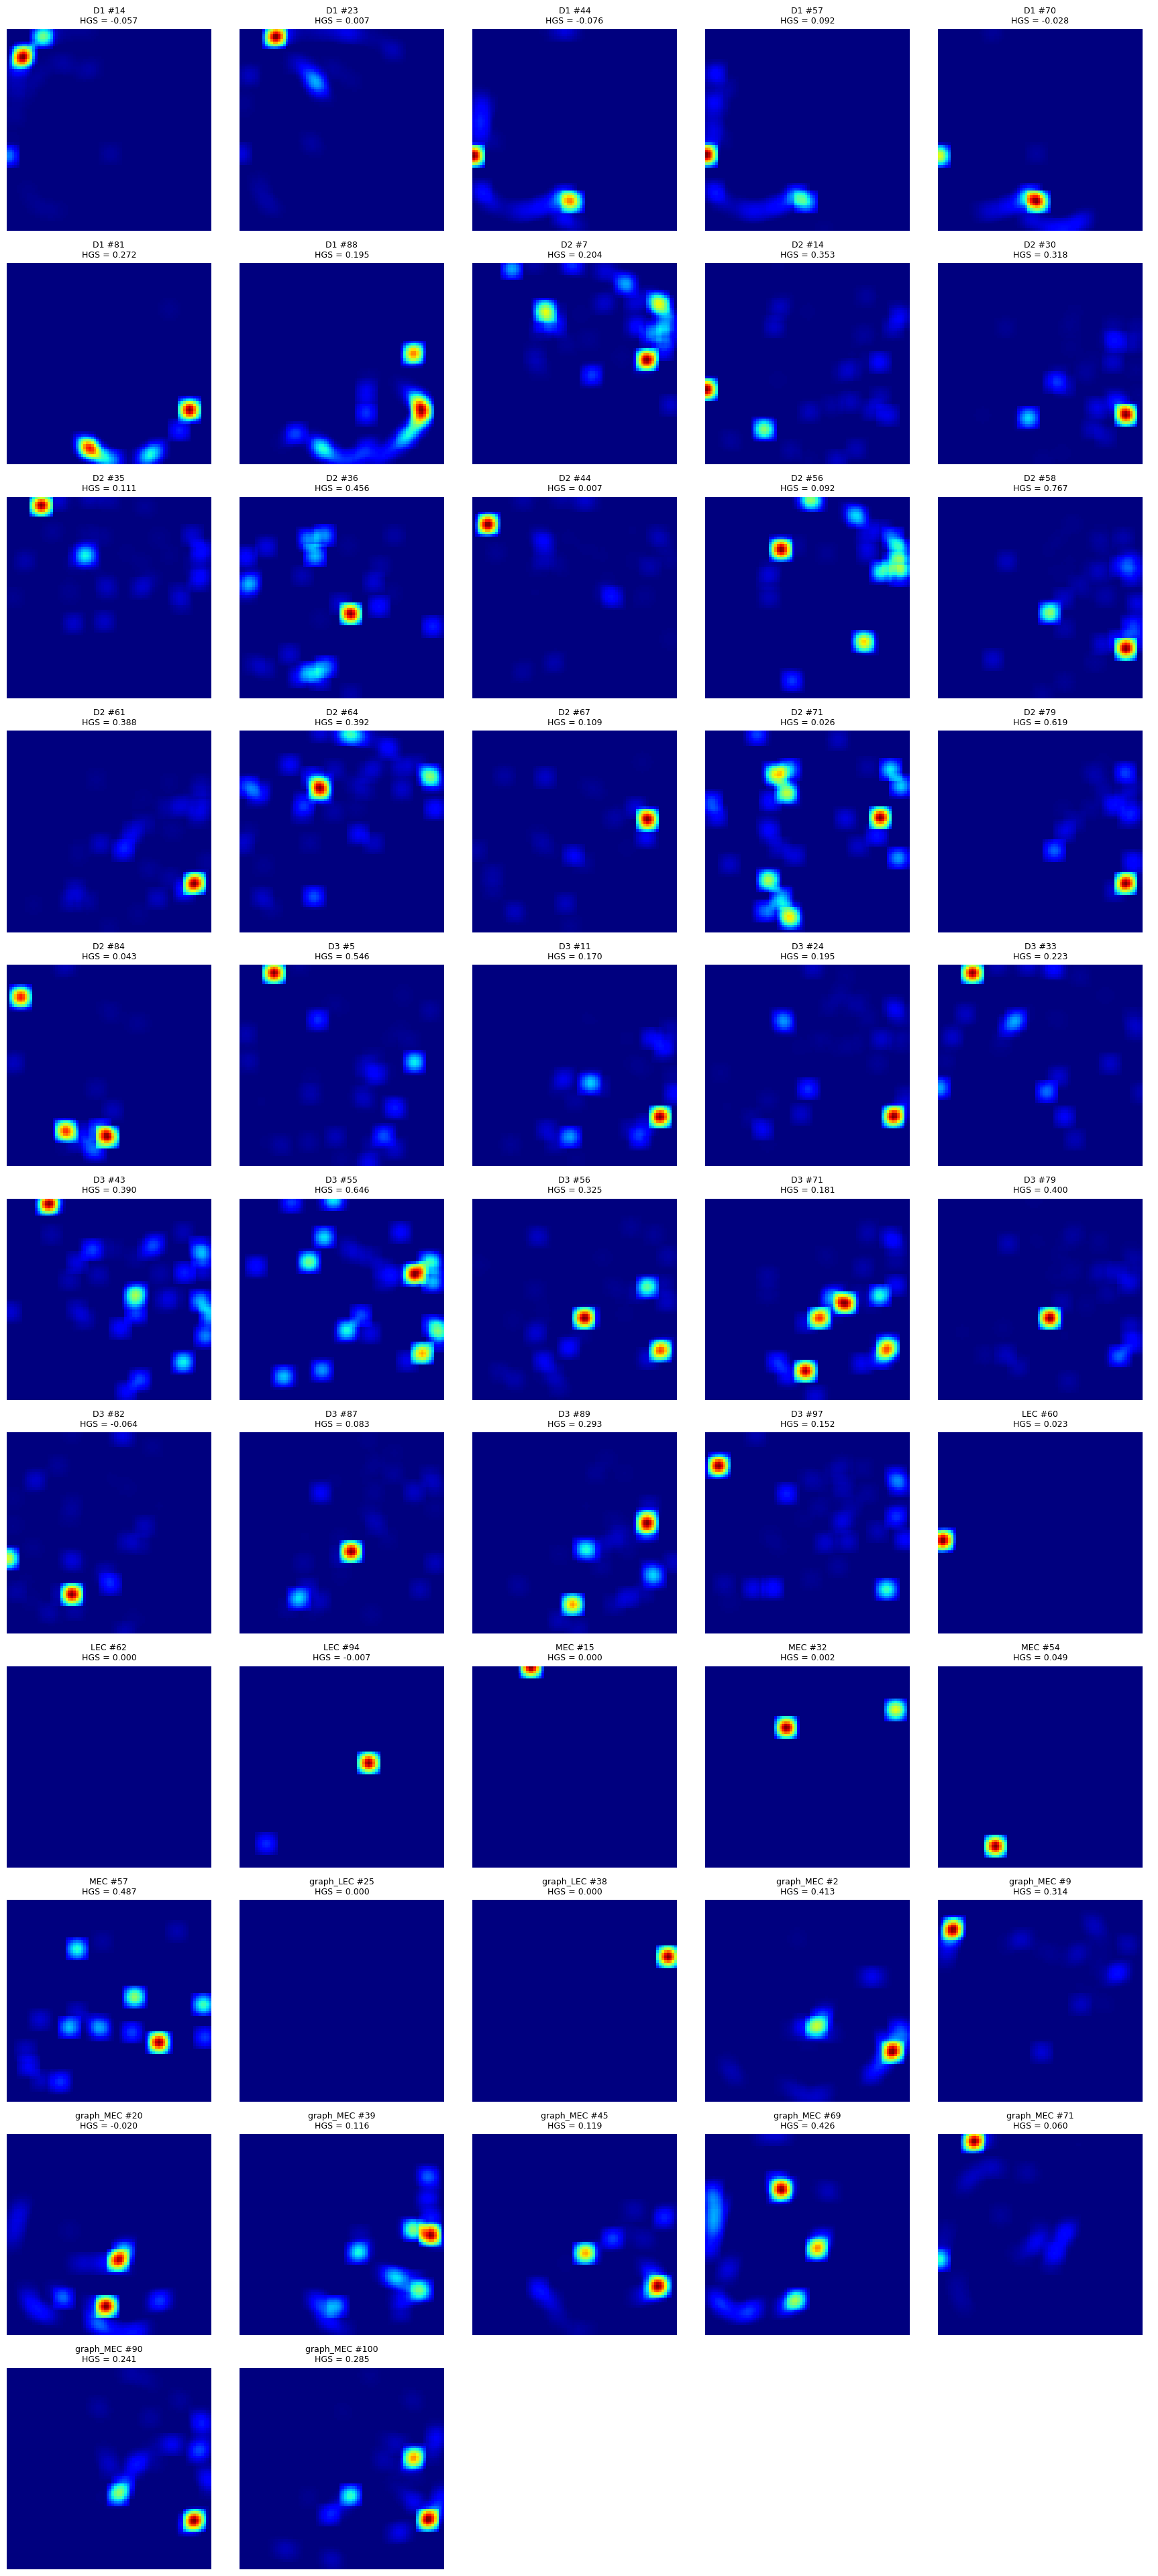

In [ ]:
import math
import matplotlib.pyplot as plt
import numpy as np

grid_cells = [r for r in results if r["is_grid_cell"]]

print(f"Found {len(grid_cells)} grid cells.")

if len(grid_cells) == 0:
    print("No grid cells detected.")

else:

    ncols = 5
    nrows = math.ceil(len(grid_cells) / ncols)

    fig, axes = plt.subplots(
        nrows,
        ncols,
        figsize=(3.5*ncols, 3.5*nrows)
    )

    axes = np.array(axes).reshape(-1)

    for ax in axes:
        ax.axis("off")

    for ax, cell in zip(axes, grid_cells):

        neuron_idx = cell["global_index"] - 1

        firing_map, extent = build_firing_rate_map(
            responses=activations[:, neuron_idx],
            pos=raw_pos,
            occupancy_map=occupancy_map,
            thresh_param=1.5,
            res_param=80,
        )

        im = ax.imshow(
            firing_map,
            origin="lower",
            extent=extent,
            cmap="jet",
            aspect="equal",
        )

        ax.set_title(
            f"{cell['layer']} #{cell['layer_neuron_index']}\n"
            f"HGS = {cell['original_hgs']:.3f}",
            fontsize=9,
        )

        ax.set_xticks([])
        ax.set_yticks([])

    plt.tight_layout()
    plt.show()

In [ ]:
## below was a test for 10 neurons.

In [48]:
grid_cells = [r for r in results if r["is_grid_cell"]]

print(f"Found {len(grid_cells)} grid cells.")

Found 52 grid cells.


In [44]:
top = sorted(results, key=lambda x: x["original_hgs"], reverse=True)

for r in top[:10]:
    print(
        f"Layer={r['layer']:10s} "
        f"Neuron={r['layer_neuron_index']:3d} "
        f"HGS={r['original_hgs']:.3f} "
        f"Grid={r['is_grid_cell']}"
    )

Layer=D2         Neuron= 58 HGS=0.767 Grid=True
Layer=D3         Neuron= 55 HGS=0.646 Grid=True
Layer=D2         Neuron= 79 HGS=0.619 Grid=True
Layer=D3         Neuron=  5 HGS=0.546 Grid=True
Layer=MEC        Neuron= 57 HGS=0.487 Grid=True
Layer=D2         Neuron= 36 HGS=0.456 Grid=True
Layer=graph_MEC  Neuron= 69 HGS=0.426 Grid=True
Layer=graph_MEC  Neuron=  2 HGS=0.413 Grid=True
Layer=D3         Neuron= 79 HGS=0.400 Grid=True
Layer=D2         Neuron= 64 HGS=0.392 Grid=True


In [36]:
for i, r in enumerate(results):
    print(
        f"Neuron {i+1:2d} | "
        f"HGS = {r['original_hgs']:.3f} | "
        f"Threshold = {r['shuffle_threshold_95']:.3f} | "
        f"Grid = {r['is_grid_cell']}"
    )

Neuron  1 | HGS = -0.059 | Threshold = 0.000 | Grid = False
Neuron  2 | HGS = -0.326 | Threshold = 0.178 | Grid = False
Neuron  3 | HGS = -0.268 | Threshold = 0.474 | Grid = False
Neuron  4 | HGS = 0.000 | Threshold = 0.000 | Grid = False
Neuron  5 | HGS = -0.183 | Threshold = 0.196 | Grid = False
Neuron  6 | HGS = -0.070 | Threshold = 0.252 | Grid = False
Neuron  7 | HGS = -0.077 | Threshold = 0.184 | Grid = False
Neuron  8 | HGS = -0.137 | Threshold = -0.098 | Grid = False
Neuron  9 | HGS = -0.271 | Threshold = 0.068 | Grid = False
Neuron 10 | HGS = -0.298 | Threshold = 0.149 | Grid = False
Neuron 11 | HGS = -0.245 | Threshold = 0.011 | Grid = False
Neuron 12 | HGS = -0.384 | Threshold = -0.011 | Grid = False
Neuron 13 | HGS = -0.334 | Threshold = 0.302 | Grid = False
Neuron 14 | HGS = -0.057 | Threshold = -0.089 | Grid = True
Neuron 15 | HGS = -0.195 | Threshold = 0.217 | Grid = False
Neuron 16 | HGS = -0.457 | Threshold = 0.184 | Grid = False
Neuron 17 | HGS = -0.093 | Threshold = 

In [37]:
result["original_map"]
result["autocorr_map"]

array([[-0.04997047, -0.05538189, -0.06096551, ..., -0.182284  ,
        -0.18119088, -0.19835457],
       [ 0.05132081,  0.05550197,  0.05922867, ..., -0.10760698,
        -0.08940065, -0.0933918 ],
       [-0.04876388, -0.0523213 , -0.05599009, ..., -0.01215917,
         0.02835314,  0.04200955],
       ...,
       [ 0.04200955,  0.02835314, -0.01215917, ..., -0.05599009,
        -0.0523213 , -0.04876388],
       [-0.0933918 , -0.08940065, -0.10760698, ...,  0.05922867,
         0.05550197,  0.05132081],
       [-0.19835457, -0.18119088, -0.182284  , ..., -0.06096551,
        -0.05538189, -0.04997047]])

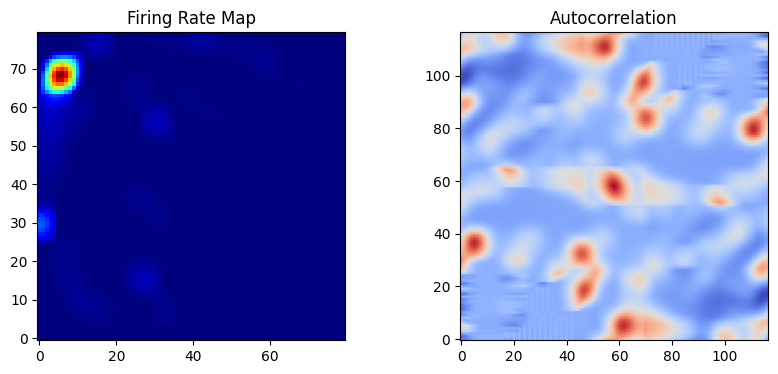

In [38]:
import matplotlib.pyplot as plt

idx = 0

fig, ax = plt.subplots(1,2, figsize=(10,4))

ax[0].imshow(results[idx]["original_map"],
             origin="lower",
             cmap="jet")

ax[0].set_title("Firing Rate Map")

ax[1].imshow(results[idx]["autocorr_map"],
             origin="lower",
             cmap="coolwarm")

ax[1].set_title("Autocorrelation")

plt.show()

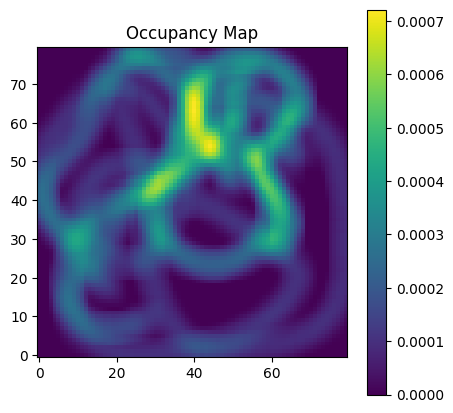

In [39]:
plt.figure(figsize=(5,5))

plt.imshow(
    occupancy_map,
    origin="lower",
    cmap="viridis"
)

plt.title("Occupancy Map")
plt.colorbar()

plt.show()